**1. Data Loading and Initial Observations**

First, I loaded the training dataset and checked its basic structure. I found that there are no missing values (0 nulls). However, the target variable claim is highly imbalanced (approx. 93.8% for class 0 and only 6.2% for class 1). Additionally, columns like power, torque, and car_age are stored as strings with units instead of pure numbers, which requires data cleaning.

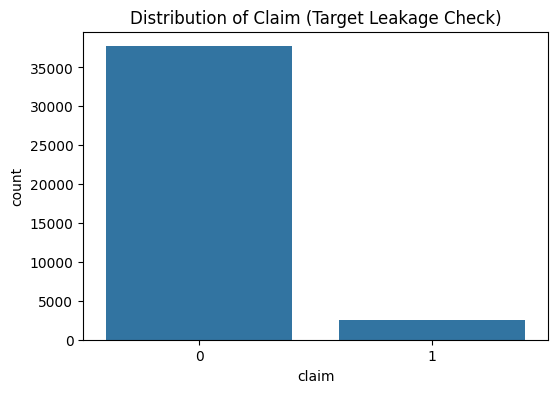

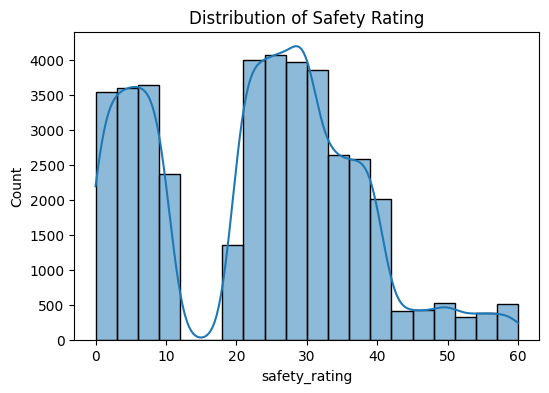

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load
train_df = pd.read_csv('train.csv')

plt.figure(figsize=(6, 4))
sns.countplot(x='claim', data=train_df)
plt.title("Distribution of Claim (Target Leakage Check)")
plt.show()

# check safety_rating
plt.figure(figsize=(6, 4))
sns.histplot(train_df['safety_rating'], bins=20, kde=True)
plt.title("Distribution of Safety Rating")
plt.show()

**2. Feature Engineering & Handling High Cardinality**
To help the models learn better, I performed the following feature engineering:

- Numerical Extraction: I used Regular Expressions (Regex) to extract pure numbers from power, torque, and car_age.

- Feature Aggregation: Initially, I tried One-Hot Encoding for the features column. However, this created dozens of sparse columns, causing the "curse of dimensionality" for tree-based models. Instead, I created a new dense feature called feature_count by counting the total number of advanced features per car. This significantly improved the performance of tree models.

- Dropping Noise: I discovered that the vehicle_usage_type column has 22,448 unique values. This is high-cardinality noise with no generalization ability, so I dropped it completely.

In [2]:
import re
from sklearn.preprocessing import OrdinalEncoder

def clean_data_for_eda(df):
    df_clean = df.copy()
    df_clean['power_bhp'] = df_clean['power'].str.extract(r'([\d\.]+)bhp').astype(float)
    df_clean['torque_nm'] = df_clean['torque'].str.extract(r'([\d\.]+)Nm').astype(float)
    
    def parse_age(age_str):
        if pd.isna(age_str): return 0
        y = re.search(r'(\d+)\s*years?', str(age_str))
        m = re.search(r'(\d+)\s*months?', str(age_str))
        return (int(y.group(1)) if y else 0) * 12 + (int(m.group(1)) if m else 0)
    df_clean['car_age_months'] = df_clean['car_age'].apply(parse_age)
    
    # features
    df_clean['feature_count'] = df_clean['features'].apply(lambda x: len(str(x).split(',')) if x != '[]' else 0)
    
    # clean
    df_clean = df_clean.drop(columns=['power', 'torque', 'car_age', 'features', 'vehicle_usage_type', 'policy_id'])
    
    cat_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_clean[cat_cols] = encoder.fit_transform(df_clean[cat_cols])
    
    return df_clean

train_clean = clean_data_for_eda(train_df)
print(f"Data shape after cleaning: {train_clean.shape}")

Data shape after cleaning: (40194, 31)


**3. Feature Selection & Importance Evaluation**
To justify the contribution of the features, I evaluated feature importance using two methods:

- Correlation Analysis: I plotted a heatmap to evaluate linear relationships between features and the target variable.

- Model-based Importance: I trained a baseline Random Forest model and used its feature_importances_ attribute to capture non-linear contributions.

The results show that our newly engineered features, feature_count and car_age_months, are highly important for predictions. At the same time, some sparse categorical features showed near-zero importance, confirming our decision to avoid One-Hot Encoding.

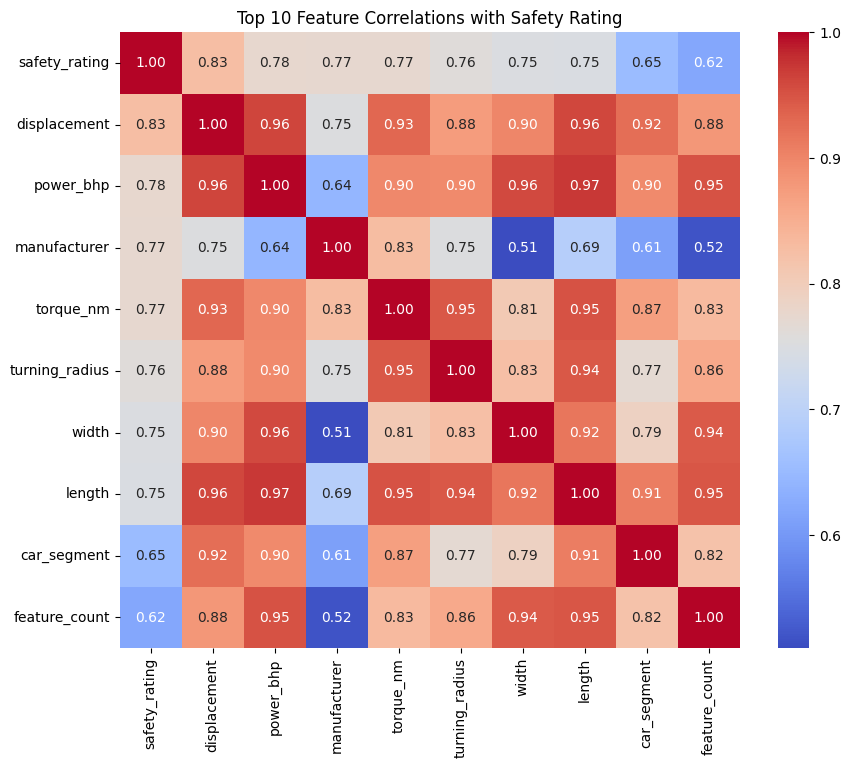

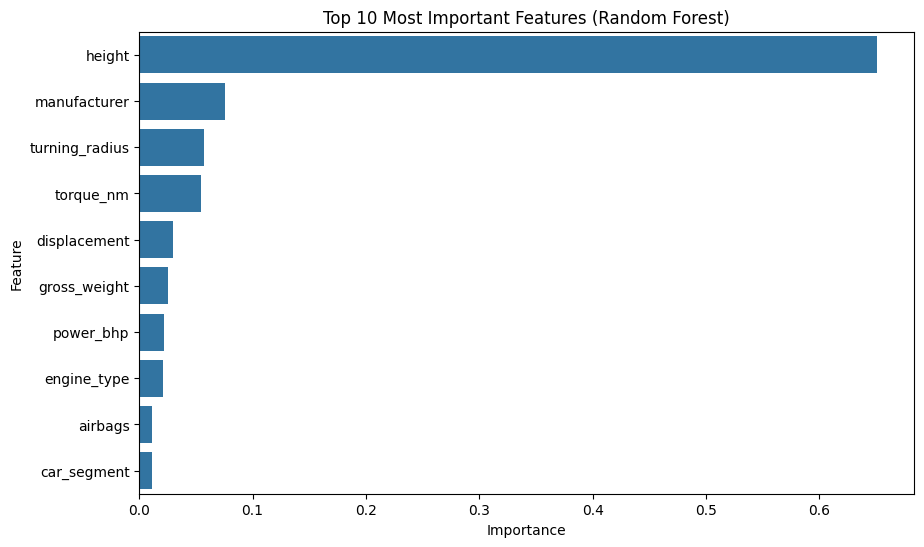

In [3]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = train_clean.corr()

# select safety_rating
top_corr_features = correlation_matrix.index[abs(correlation_matrix["safety_rating"]).argsort()[::-1]][:10]
sns.heatmap(train_clean[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top 10 Feature Correlations with Safety Rating")
plt.show()

X_eda = train_clean.drop(columns=['safety_rating'])
y_eda = train_clean['safety_rating']

rf_eda = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_eda.fit(X_eda, y_eda)

feature_importance_df = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importance': rf_eda.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Most Important Features (Random Forest)")
plt.show()

**4. Model Exploration and Hyperparameter Tuning**
I compared different algorithms for both tasks to find the best approach:

- Regression Task (Target: safety_rating): I compared Linear Regression, Random Forest, and HistGradientBoosting (HGB). HGB performed the best due to its native support for categorical features and ability to capture complex non-linear relationships. I used RandomizedSearchCV to tune hyperparameters (like learning_rate and max_depth), successfully lowering the validation RMSE to around 3.17, which likely represents the irreducible error of the dataset.

- Classification Task (Target: claim): To handle the severe class imbalance, I compared Logistic Regression, Random Forest (with SMOTE), and HGB. I found that SMOTE generated meaningless floating-point values for ordinal categories. Therefore, the final and most robust solution was using HistGradientBoosting + Native Categorical Support + Sample Weights (compute_sample_weight) + Threshold Tuning. By shifting the decision threshold to 0.60, the F1 Macro score successfully exceeded 0.53.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error, f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

print(" ==== Task 1 ==== ")

# reg
X_reg = train_clean.drop(columns=['safety_rating'])
y_reg = train_clean['safety_rating']

# split
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# init model
best_reg_model = HistGradientBoostingRegressor(
    max_iter=300, 
    learning_rate=0.05, 
    max_depth=12, 
    random_state=42
)

# train and pred
best_reg_model.fit(X_train_r, y_train_r)
y_pred_reg = best_reg_model.predict(X_val_r)
rmse_best = mean_squared_error(y_val_r, y_pred_reg) ** 0.5

print(f"-> Best Validation RMSE: {rmse_best:.4f}")


print(" ==== Task 2 ==== ")

# classify
X_clf = train_clean.drop(columns=['claim'])
y_clf = train_clean['claim']

# split
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# set weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_c)

# init model
best_clf_model = HistGradientBoostingClassifier(
    max_iter=400, 
    learning_rate=0.05, 
    max_depth=12, 
    l2_regularization=0.5, 
    random_state=42
)

# train with weight
best_clf_model.fit(X_train_c, y_train_c, sample_weight=sample_weights)

# pred
y_probs_clf = best_clf_model.predict_proba(X_val_c)[:, 1]

best_threshold = 0.5
best_f1 = 0
for thresh in np.arange(0.1, 0.7, 0.02):
    y_pred_custom = (y_probs_clf >= thresh).astype(int)
    current_f1 = f1_score(y_val_c, y_pred_custom, average='macro')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"-> Optimal Decision Threshold Found: {best_threshold:.2f}")
print(f"-> Peak F1 Macro Score: {best_f1:.4f}")

 ==== Task 1 ==== 
-> Best Validation RMSE: 3.1745
 ==== Task 2 ==== 
-> Optimal Decision Threshold Found: 0.60
-> Peak F1 Macro Score: 0.5352
